In [1]:
import yarp as yp
from yarp.reaction.generate_rxns import enumerate_products

In [2]:
def get_overlaps(plist1, plist2):
    ids1 = {y.hash: y for y in plist1}
    ids2 = {y.hash: y for y in plist2}

    overlap = set(ids1) & set(ids2)

    prods = []
    for oid in overlap:
        yp = ids1.get(oid)
        prods.append(yp)

    return prods

def get_unique(plist1, plist2):
    ids1 = {y.hash: y for y in plist1}
    ids2 = {y.hash: y for y in plist2}

    unique_ids = set(ids1) - set(ids2)

    prods = []
    for oid in unique_ids:
        prods.append(ids1[oid])

    return prods

# Let's start with CC=O

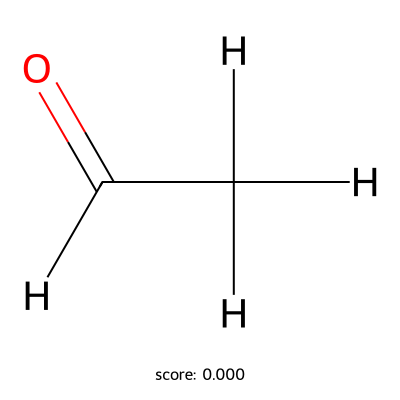

In [3]:
haa = yp.yarpecule("CC=O")
haa.draw_bmats(show_inline=True)

## Sequential b2f2 of CC=O

Product enumeration with break 2, form 2 will be performed in sequential mode.
 * WARNING: Sequential mode is expensive and may cause memory blow-up issues!
 - Breaking 2 bonds formed 6 intermediates
 - Forming 2 bonds formed 24 potential products
 - 3 cleaned products after filtering


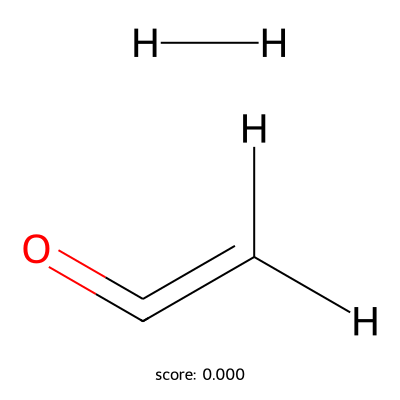

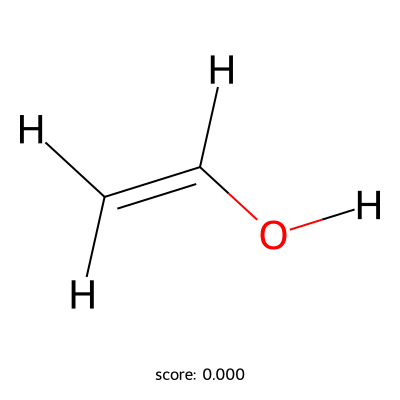

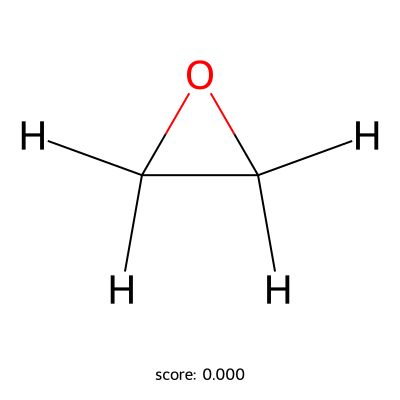

In [4]:
haa_seq_prod = enumerate_products(haa, 2, 2, mode="sequential", cutoff=0.0, ring_mode=False)
for _ in haa_seq_prod:
    _.draw_bmats(show_inline=True)

Product enumeration with break 2, form 2 will be performed in sequential mode.
 * WARNING: Sequential mode is expensive and may cause memory blow-up issues!
 - Breaking 2 bonds formed 6 intermediates
 - Forming 2 bonds formed 24 potential products
 - 1 cleaned products after filtering


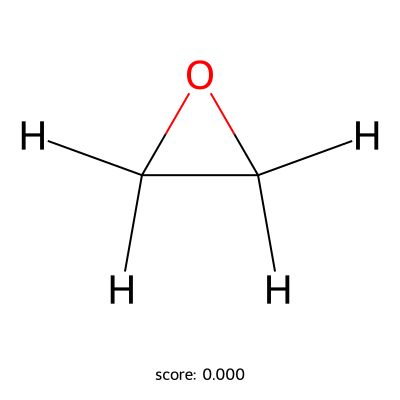

In [5]:
haa_seq_prod_rings = enumerate_products(haa, 2, 2, mode="sequential", cutoff=0.0, ring_mode=True)
for _ in haa_seq_prod_rings:
    _.draw_bmats(show_inline=True)

## Concerted b2f2 of CC=O

Product enumeration with break 2, form 2 will be performed in concerted mode.
 - Enumerated 4 products


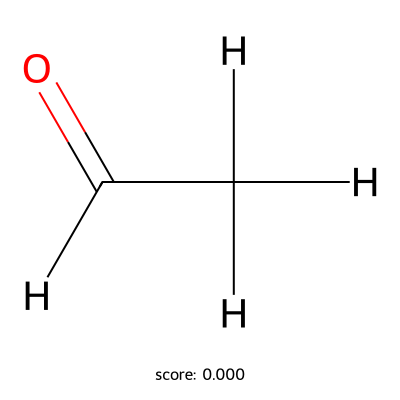

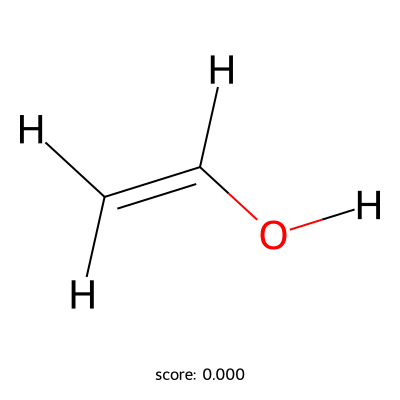

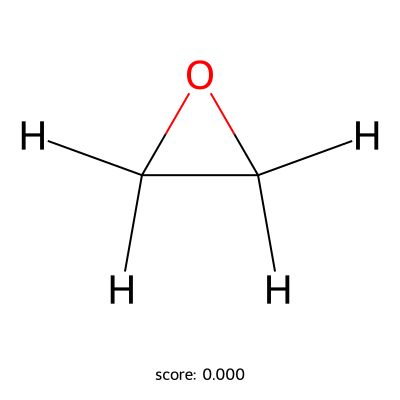

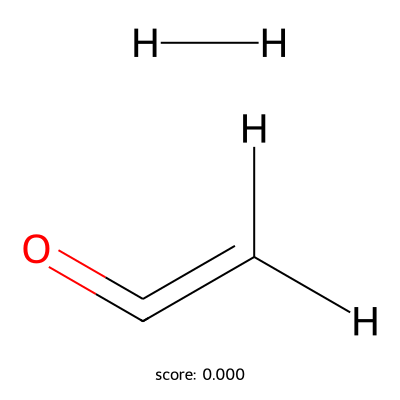

In [6]:
haa_conc_prod = enumerate_products(haa, 2, 2, mode="concerted")
for _ in haa_conc_prod:
    _.draw_bmats(show_inline=True)

# What about pyridine?

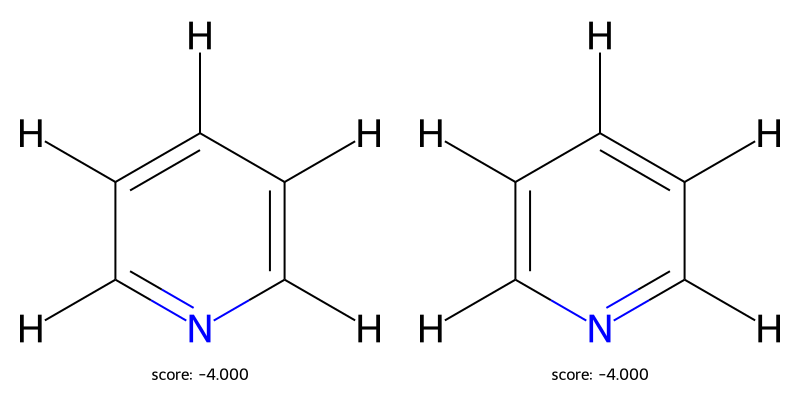

In [7]:
pyridine = yp.yarpecule("n1ccccc1")
pyridine.draw_bmats(show_inline=True)

## Sequential b2f2

In [8]:
pyr_seq_prod = enumerate_products(pyridine, 2, 2, mode="sequential", cutoff=0.0, ring_mode=False)
# for _ in pyr_seq_prod:
#     _.draw_bmats(show_inline=True)

Product enumeration with break 2, form 2 will be performed in sequential mode.
 * WARNING: Sequential mode is expensive and may cause memory blow-up issues!
 - Breaking 2 bonds formed 40 intermediates
 - Forming 2 bonds formed 3729 potential products
 - 240 cleaned products after filtering


In [9]:
pyr_seq_prod_rings = enumerate_products(pyridine, 2, 2, mode="sequential", cutoff=0.0, ring_mode=True)
# for _ in pyr_seq_prod_rings:
#     _.draw_bmats(show_inline=True)

Product enumeration with break 2, form 2 will be performed in sequential mode.
 * WARNING: Sequential mode is expensive and may cause memory blow-up issues!
 - Breaking 2 bonds formed 40 intermediates
 - Forming 2 bonds formed 3729 potential products
 - 236 cleaned products after filtering


## Concerted b2f2

Product enumeration with break 2, form 2 will be performed in concerted mode.
 - Enumerated 6 products


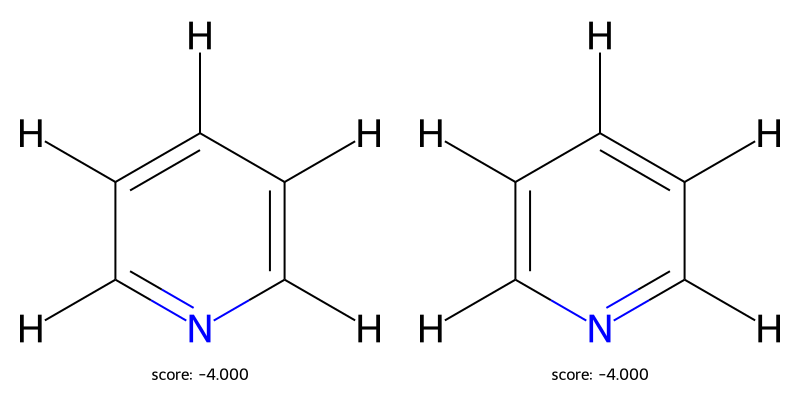

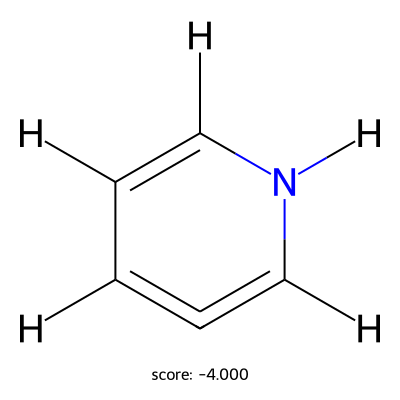

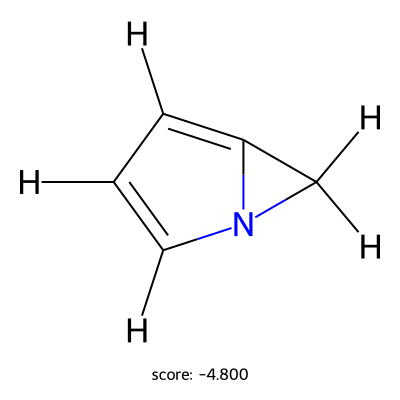

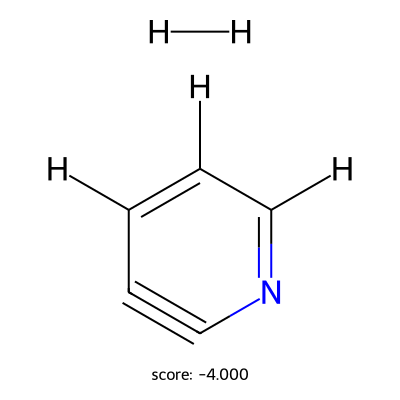

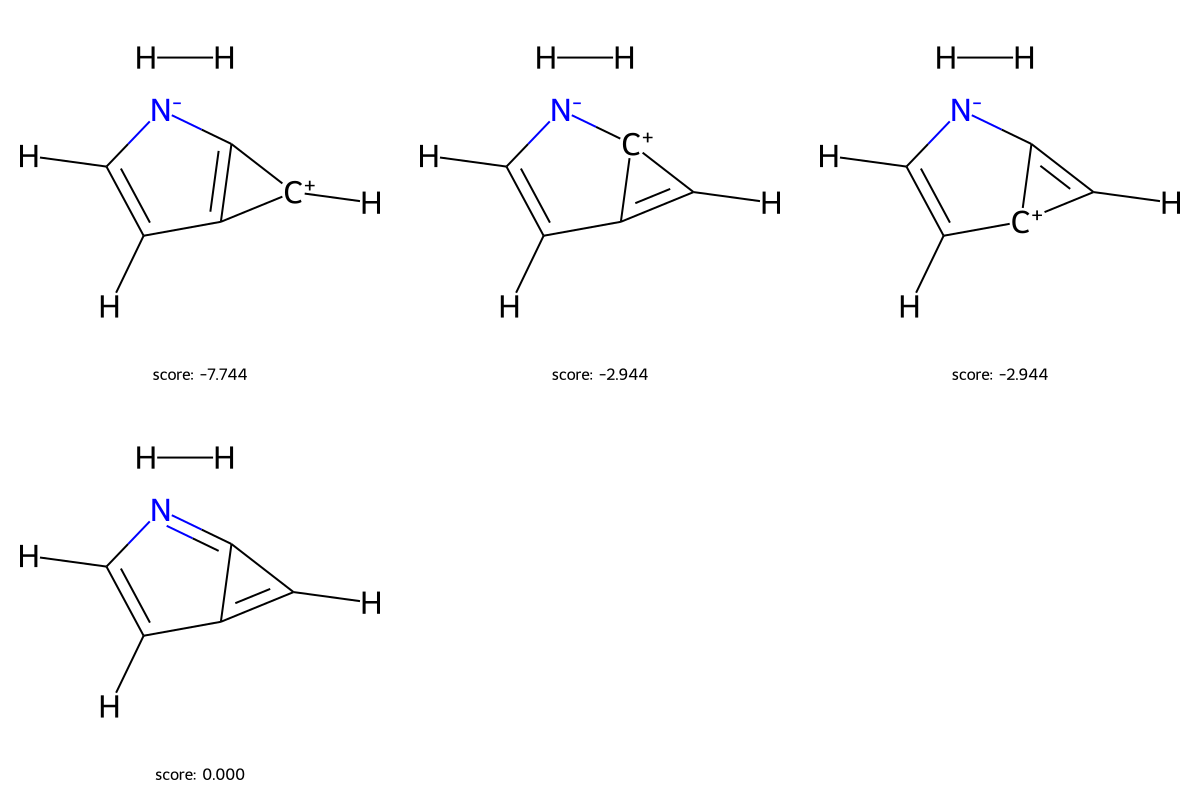

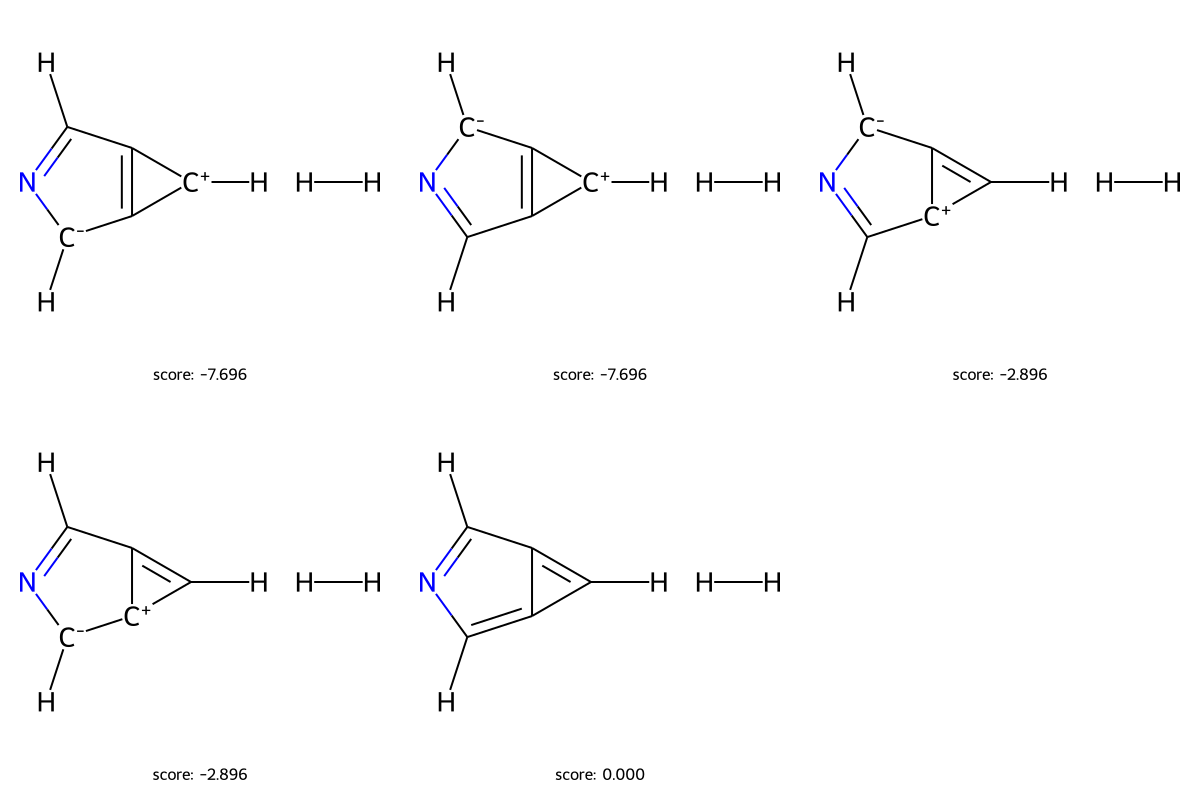

In [10]:
pyr_conc_prod = enumerate_products(pyridine, 2, 2, mode="concerted")
for _ in pyr_conc_prod:
    _.draw_bmats(show_inline=True)

## Comparing generated product sets

### Comparing sequential w/ ring filtering vs sequential no ring filtering

Structures removed by ring filtering:


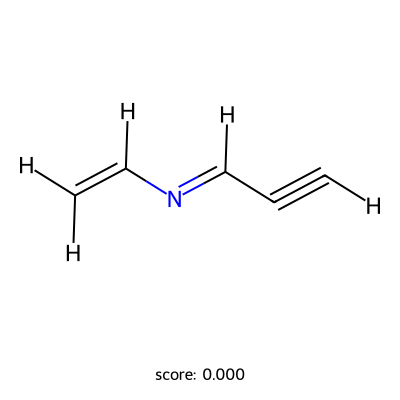

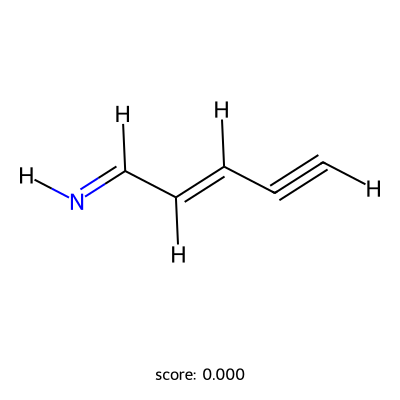

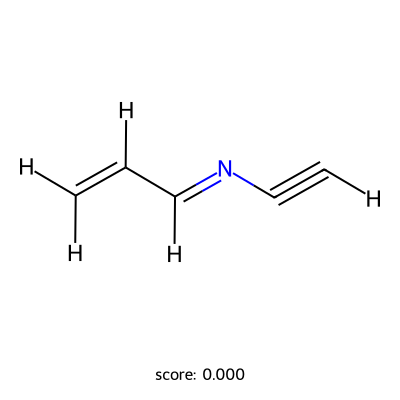

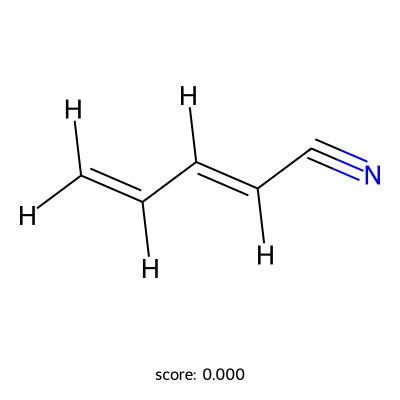

In [11]:
seq_unique = get_unique(pyr_seq_prod, pyr_seq_prod_rings)
print("Structures removed by ring filtering:")
for _ in seq_unique:
    _.draw_bmats(show_inline=True)

### Comparing concerted with sequential (w/ ring filtering)

In [12]:
conc_overlap = get_overlaps(pyr_conc_prod, pyr_seq_prod_rings)
print("Structures found by both concerted and sequential enumeration:")
for _ in conc_overlap:
    _.draw_bmats(show_inline=True)

Structures found by both concerted and sequential enumeration:


# Let's move on to glucose pyrolysis

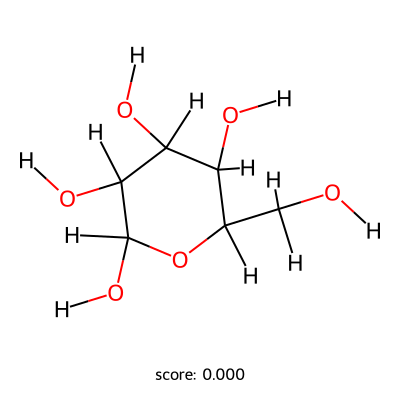

In [13]:
glucose = yp.yarpecule("C(O)1OC(CO)C(O)C(O)C(O)1")
glucose.draw_bmats(show_inline=True)

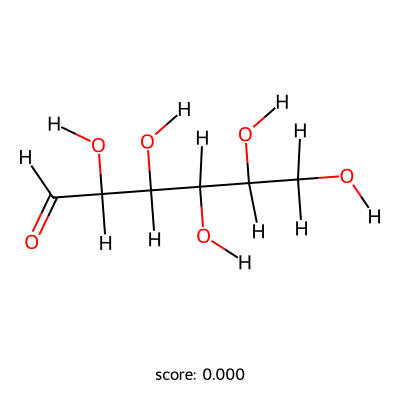

In [14]:
glu_p1 = yp.yarpecule ("OCC(O)C(O)C(O)C(O)C=O")
glu_p1.draw_bmats(show_inline=True)

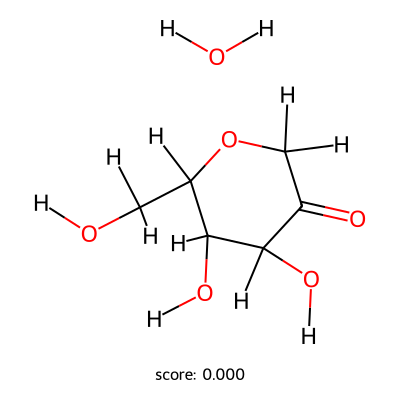

In [15]:
glu_p2 = yp.yarpecule("O.OCC1C(O)C(O)C(=O)CO1")
glu_p2.draw_bmats(show_inline=True)

## Concerted b2f2 enumeration

In [16]:
glu_conc_prod = enumerate_products(glucose, 2, 2, mode="concerted")


Product enumeration with break 2, form 2 will be performed in concerted mode.
 - Enumerated 299 products


In [17]:
print("Concerted enumeration matches with known glucose products:")
overlap = get_overlaps(glu_conc_prod, [glu_p1, glu_p2])
for _ in overlap:
    _.draw_bmats(show_inline=True)

Concerted enumeration matches with known glucose products:


## Sequential b2f2 enumeration

In [18]:
glu_seq_prod = enumerate_products(glucose, 2, 2, mode="sequential", cutoff=0.0, ring_mode=False)

Product enumeration with break 2, form 2 will be performed in sequential mode.
 * WARNING: Sequential mode is expensive and may cause memory blow-up issues!
 - Breaking 2 bonds formed 276 intermediates
 - Forming 2 bonds formed 869 potential products
 - 135 cleaned products after filtering


Sequential enumeration (no ring filtering) matches with known glucose products:


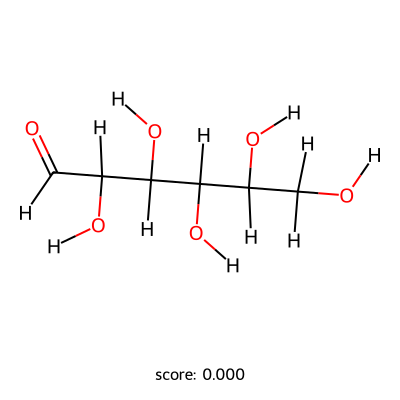

In [19]:
print("Sequential enumeration (no ring filtering) matches with known glucose products:")
overlap = get_overlaps(glu_seq_prod, [glu_p1, glu_p2])
for _ in overlap:
    _.draw_bmats(show_inline=True)

In [20]:
glu_seq_prod_rings = enumerate_products(glucose, 2, 2, mode="sequential", cutoff=0.0, ring_mode=True)

Product enumeration with break 2, form 2 will be performed in sequential mode.
 * WARNING: Sequential mode is expensive and may cause memory blow-up issues!
 - Breaking 2 bonds formed 276 intermediates
 - Forming 2 bonds formed 869 potential products
 - 127 cleaned products after filtering


In [21]:
print("Sequential enumeration (w/ ring filtering) matches with known glucose products:")
overlap = get_overlaps(glu_seq_prod_rings, [glu_p1, glu_p2])
for _ in overlap:
    _.draw_bmats(show_inline=True)

Sequential enumeration (w/ ring filtering) matches with known glucose products:
